In [2]:
!unzip -q deepfake.zip -d /content/dataset

In [3]:
!ls /content/dataset

real_and_fake_face  real_and_fake_face_detection


In [6]:
import os
import cv2
import numpy as np
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- 1. CONFIGURATION (AUTO-DETECT PATHS) ---
base_extract_path = "/content/dataset"
REAL_FACES_DIR = None
FAKE_FACES_DIR = None

# Let Python hunt through the extracted files to find the exact folders
for root, dirs, files in os.walk(base_extract_path):
    for dir_name in dirs:
        # Looking for folders that indicate 'real' or 'fake'
        if "real" in dir_name.lower() and "fake" not in dir_name.lower():
            REAL_FACES_DIR = os.path.join(root, dir_name)
        elif "fake" in dir_name.lower() and "real" not in dir_name.lower():
            FAKE_FACES_DIR = os.path.join(root, dir_name)

print(f"✅ Found Real Faces at: {REAL_FACES_DIR}")
print(f"✅ Found Fake Faces at: {FAKE_FACES_DIR}")

if not REAL_FACES_DIR or not FAKE_FACES_DIR:
    raise ValueError("Could not find the real/fake folders. Did the zip extract correctly?")

# LBP Texture Math Settings
RADIUS = 1
N_POINTS = 8 * RADIUS

def extract_lbp_features(image_path):
    """Reads an image, turns it grayscale, and extracts texture math."""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Resize to make the math run fast on the CPU
    img = cv2.resize(img, (128, 128))

    # Extract the Local Binary Pattern
    lbp = local_binary_pattern(img, N_POINTS, RADIUS, method="uniform")

    # Create a histogram of the textures
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, N_POINTS + 3), range=(0, N_POINTS + 2))

    # Normalize the numbers
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# --- 2. DATA INGESTION ---
print("Extracting features from images. This might take a minute...")
X = [] # Holds the texture numbers
y = [] # Holds the labels (0 for Fake, 1 for Real)

# We are limiting this to 500 images each just to test the pipeline quickly.
# Once it works, you can remove the [:500] to train on the whole dataset!
print("Processing Fake Images...")
for img_name in os.listdir(FAKE_FACES_DIR)[:500]:
    features = extract_lbp_features(os.path.join(FAKE_FACES_DIR, img_name))
    if features is not None:
        X.append(features)
        y.append(0)

print("Processing Real Images...")
for img_name in os.listdir(REAL_FACES_DIR)[:500]:
    features = extract_lbp_features(os.path.join(REAL_FACES_DIR, img_name))
    if features is not None:
        X.append(features)
        y.append(1)

X = np.array(X)
y = np.array(y)
print(f"Successfully processed {len(X)} images.")

# --- 3. TRAINING THE CLASSICAL BASELINE ---
# Split into 80% studying, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training the Random Forest Classifier...")
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# --- 4. THE EXAM (Evaluating Accuracy) ---
predictions = clf.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("\n" + "="*40)
print(f"PHASE 1 COMPLETE: Classical ML Baseline")
print(f"Accuracy: {accuracy * 100:.2f}%")
print("="*40)
print(classification_report(y_test, predictions, target_names=["Fake", "Real"]))

✅ Found Real Faces at: /content/dataset/real_and_fake_face_detection/real_and_fake_face/training_real
✅ Found Fake Faces at: /content/dataset/real_and_fake_face_detection/real_and_fake_face/training_fake
Extracting features from images. This might take a minute...
Processing Fake Images...
Processing Real Images...
Successfully processed 1000 images.
Training the Random Forest Classifier...

PHASE 1 COMPLETE: Classical ML Baseline
Accuracy: 49.50%
              precision    recall  f1-score   support

        Fake       0.48      0.54      0.51        96
        Real       0.52      0.45      0.48       104

    accuracy                           0.49       200
   macro avg       0.50      0.50      0.49       200
weighted avg       0.50      0.49      0.49       200



In [1]:
!pip install -q transformers datasets evaluate accelerate scikit-learn

In [8]:
from datasets import load_dataset
from transformers import ViTImageProcessor, ViTForImageClassification, TrainingArguments, Trainer
import torch
import numpy as np
import evaluate

print("Loading dataset into Hugging Face...")
# Point this to the parent folder that contains the real and fake subfolders
data_dir = "/content/dataset/real_and_fake_face_detection/real_and_fake_face"
dataset = load_dataset("imagefolder", data_dir=data_dir, split="train")

# Split into 80% training (studying) and 20% testing (the exam)
dataset = dataset.train_test_split(test_size=0.2, seed=42)

print("Downloading the blank Vision Transformer brain...")
model_name = "google/vit-base-patch16-224-in21k"
processor = ViTImageProcessor.from_pretrained(model_name)

# This function chops the images into 16x16 pixel patches for the ViT
def transform(example_batch):
    inputs = processor([img.convert("RGB") for img in example_batch["image"]], return_tensors="pt")
    inputs["labels"] = example_batch["label"]
    return inputs

print("Processing images into tensors (This takes a moment)...")
prepared_ds = dataset.with_transform(transform)

# Load the model and tell it there are only 2 possible answers
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "Fake", 1: "Real"},
    label2id={"Fake": 0, "Real": 1}
)

metric = evaluate.load("accuracy")

def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    return metric.compute(predictions=predictions, references=p.label_ids)

# --- THE TRAINING RULES ---
training_args = TrainingArguments(
    output_dir="./deepscan-vit-model",
    per_device_train_batch_size=16,
    eval_strategy="epoch",          # <--- Change this line!
    save_strategy="epoch",
    num_train_epochs=10,
    learning_rate=2e-5,
    remove_unused_columns=False,
    logging_steps=10,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=prepared_ds["train"],
    eval_dataset=prepared_ds["test"],
    compute_metrics=compute_metrics,
)

print("\n" + "="*40)
print("STARTING DEEP LEARNING TRAINING (Phase 2)")
print("="*40)
trainer.train()

Loading dataset into Hugging Face...


Resolving data files:   0%|          | 0/2041 [00:00<?, ?it/s]

Processing images into tensors (This takes a moment)...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1020, training_loss=0.20041943271370494, metrics={'train_runtime': 1513.7115, 'train_samples_per_second': 10.781, 'train_steps_per_second': 0.674, 'total_flos': 1.2646692705101414e+18, 'train_loss': 0.20041943271370494, 'epoch': 10.0})

=== LIVE DEEPFAKE DETECTOR ===
Click the button below to upload a test image:


Saving real_00007.jpg to real_00007.jpg

Scanning 'real_00007.jpg' with both pipelines...



Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

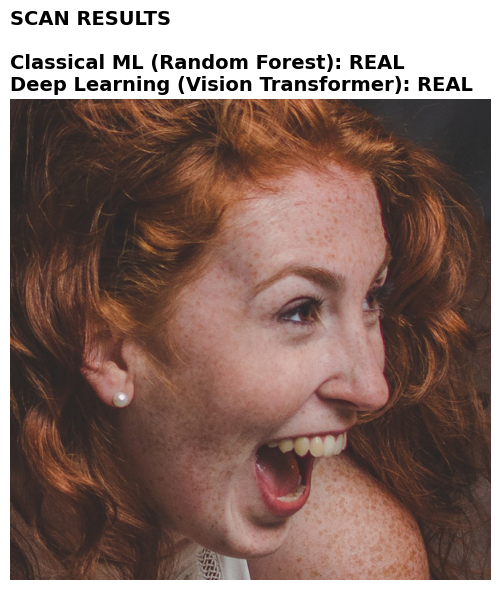

In [18]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from transformers import ViTImageProcessor, ViTForImageClassification
from google.colab import files

print("=== LIVE DEEPFAKE DETECTOR ===")
print("Click the button below to upload a test image:")

# --- 1. THE INTERACTIVE UPLOAD WIDGET ---
uploaded = files.upload()

if not uploaded:
    print("No image was uploaded. Please run the cell again.")
else:
    # Automatically get the name of the file you just uploaded
    IMAGE_PATH = list(uploaded.keys())[0]

    # --- THE FIX: This now points to your actual trained folder! ---
    MODEL_DIR = "./deepscan-vit-model/checkpoint-306"

    # Phase 1 Settings
    RADIUS = 1
    N_POINTS = 8 * RADIUS

    print(f"\nScanning '{IMAGE_PATH}' with both pipelines...\n")

    # Safely load the image for display BEFORE the AI scans it
    img_pil = Image.open(IMAGE_PATH).convert("RGB")

    # --- 2. PHASE 1: RANDOM FOREST SCAN ---
    try:
        img_cv = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
        img_cv_resized = cv2.resize(img_cv, (128, 128))

        lbp = local_binary_pattern(img_cv_resized, N_POINTS, RADIUS, method="uniform")
        (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, N_POINTS + 3), range=(0, N_POINTS + 2))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-7)

        # Ask the Random Forest for its guess
        rf_prediction_num = clf.predict([hist])[0]
        rf_verdict = "Real" if rf_prediction_num == 1 else "Fake"
    except NameError:
        rf_verdict = "ERROR: You forgot to run the Phase 1 training cell!"
    except Exception as e:
        rf_verdict = f"ERROR: {e}"

    # --- 3. PHASE 3: VISION TRANSFORMER SCAN ---
    try:
        processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
        vit_model = ViTForImageClassification.from_pretrained(MODEL_DIR)

        inputs = processor(images=img_pil, return_tensors="pt")

        with torch.no_grad():
            outputs = vit_model(**inputs)
            predicted_class_idx = outputs.logits.argmax(-1).item()

        vit_verdict = vit_model.config.id2label[predicted_class_idx]
    except Exception as e:
        vit_verdict = f"ERROR: {e}"

    # --- 4. THE GRAND REVEAL ---
    plt.figure(figsize=(8, 6))
    plt.imshow(img_pil)
    plt.axis('off')

    # Build the comparison text for the presentation
    title_text = (
        f"SCAN RESULTS\n\n"
        f"Classical ML (Random Forest): {rf_verdict.upper()}\n"
        f"Deep Learning (Vision Transformer): {vit_verdict.upper()}"
    )

    # Display the image with the text on top
    plt.title(title_text, fontsize=14, fontweight='bold', loc='left')
    plt.tight_layout()
    plt.show()

    # Clean up the file so you can run the cell again with a new image
    if os.path.exists(IMAGE_PATH):
        os.remove(IMAGE_PATH)